# Cell clustering with HGNN's embeddings.

In [8]:
import numpy as np
import json
import matplotlib.pyplot as plt
from scoit.cell_analysis import *
from hgnn.hypergraph import *

cluster_results = {}

def plot_embedding(data, feature, loss, cell_stage, **kwargs):
    subdir = f'{data}-{feature}-{loss}'
    embedding_dir = f'./embeddings/hgnn/{subdir}'
    cell_embeddings = np.load(f'{embedding_dir}/mymodel_0.npy')
    res = umap_visualize(cell_embeddings, cell_stage, **kwargs)
    plt.title(f'{data}-{feature}-{loss}')
    cluster_results[subdir] = res
    return res


## sc-GEM

In [2]:
hg = load_graph('./data/sc_GEM', load_edges=False)

load_edges=False
Load nodes in 0.00 seconds.
Num nodes: 287, Num edges: NaN
Metadata: {'dataname': 'sc_GEM', 'filter_edge': False, 'num_cells': 224, 'num_genes': 61, 'num_omics': 2, 'num_nodes': 287, 'orig_edges': 13664, 'num_edges': 13664, 'omics_offset': 0, 'gene_offset': 2, 'cell_offset': 63, 'omics_dims': [59, 59], 'raw_data': {'expr': './data/sc_GEM/expression_data.csv', 'methy': './data/sc_GEM/methylation_data.csv'}, 'cell_key': 'Cell ID', 'normalize_stats': [], 'normalization': True, 'train_size': 0.8}


In [3]:
cell_stage = hg.cell_names.str.split('_').map(lambda x: x[0])

{'NMI': 0.4309444875371437,
 'ARI': 0.2718079571287105,
 'FMI': 0.38389801855752664}

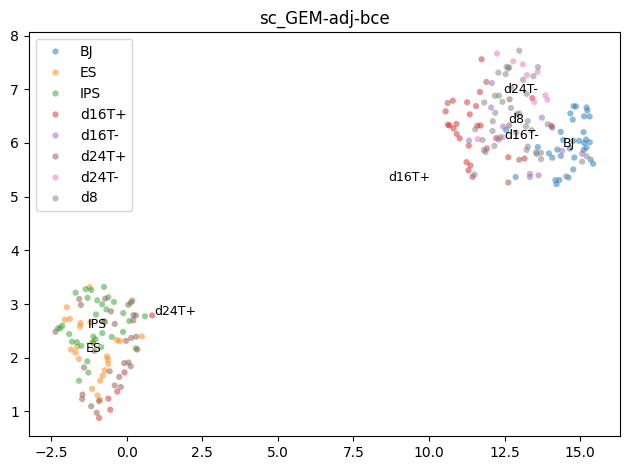

In [9]:
plot_embedding('sc_GEM', 'adj', 'bce', cell_stage, s=20)

ES, IPS, d24T+ are in one group.

Others are in the other group.

{'NMI': 0.45460749845035536, 'ARI': 0.3096678550116637, 'FMI': 0.4027769595678}

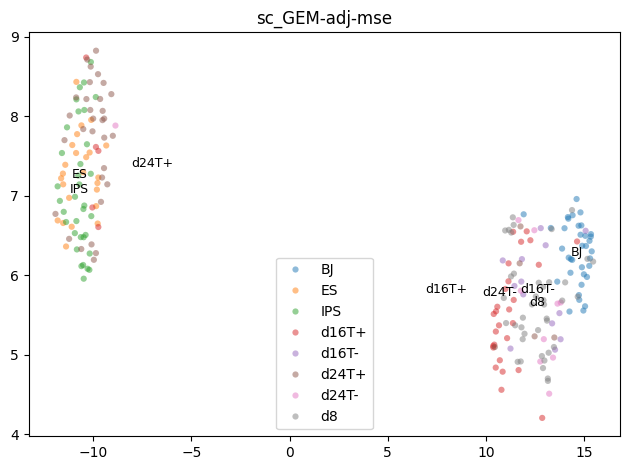

In [10]:
plot_embedding('sc_GEM', 'adj', 'mse', cell_stage, s=20)


{'NMI': 0.37982871110153354,
 'ARI': 0.2241532744892416,
 'FMI': 0.33910490033933255}

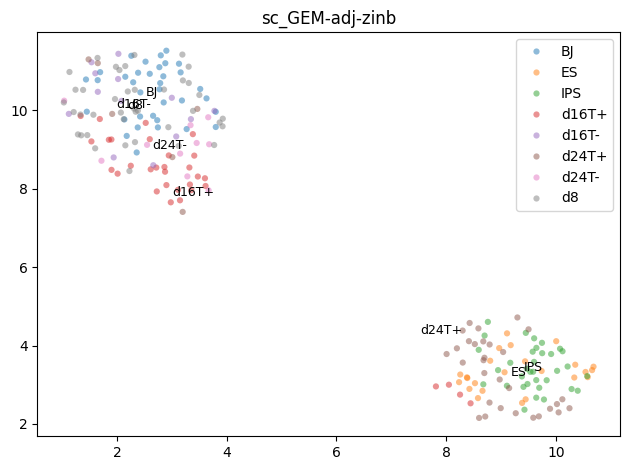

In [11]:
plot_embedding('sc_GEM', 'adj', 'zinb', cell_stage, s=20)


## PEA-STA

In [12]:
hg = load_graph('./data/PEA_STA', load_edges=False)

load_edges=False
Load nodes in 0.00 seconds.
Num nodes: 378, Num edges: NaN
Metadata: {'dataname': 'PEA_STA', 'filter_edge': False, 'num_cells': 210, 'num_genes': 166, 'num_omics': 2, 'num_nodes': 378, 'orig_edges': 34860, 'num_edges': 34860, 'omics_offset': 0, 'gene_offset': 2, 'cell_offset': 168, 'omics_dims': [141, 141], 'raw_data': {'expr': './data/PEA_STA/expression_data.csv', 'protein': './data/PEA_STA/protein_data.csv'}, 'cell_key': 'Cells ', 'normalization': True, 'train_size': 0.8, 'weight_min': 0.0, 'weight_max': 9.391}


In [13]:
# cell_stage = hg.cell_names.str.split('_').map(lambda x: x[1:-1]).str.join('_')
cell_stage = json.load(open('./data/PEA_STA/cell_stage.json', 'r'))

{'NMI': 0.28329009316045345,
 'ARI': 0.26019467333136337,
 'FMI': 0.5258314149842058}

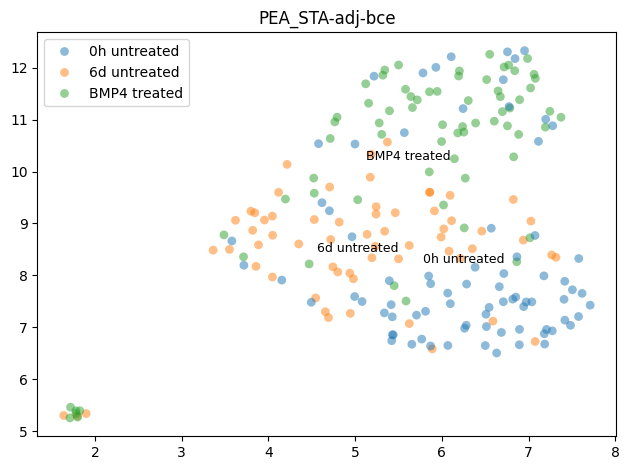

In [14]:
plot_embedding('PEA_STA', 'adj', 'bce', cell_stage)


{'NMI': 0.1375386337890713,
 'ARI': 0.13295449730586406,
 'FMI': 0.43102106809084656}

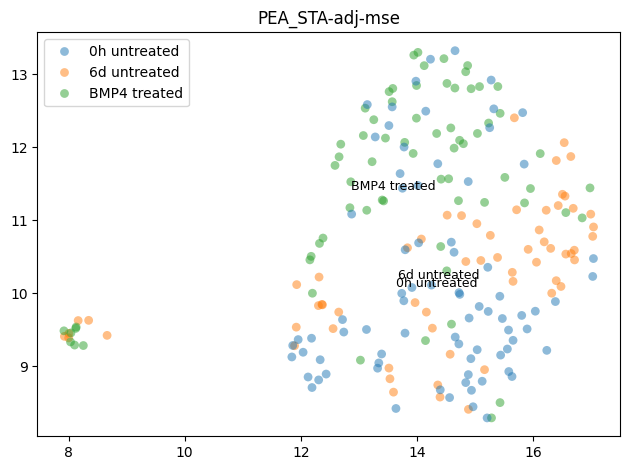

In [15]:
plot_embedding('PEA_STA', 'adj', 'mse', cell_stage)


{'NMI': 0.28036420780959687,
 'ARI': 0.2517220514673816,
 'FMI': 0.5594096813772377}

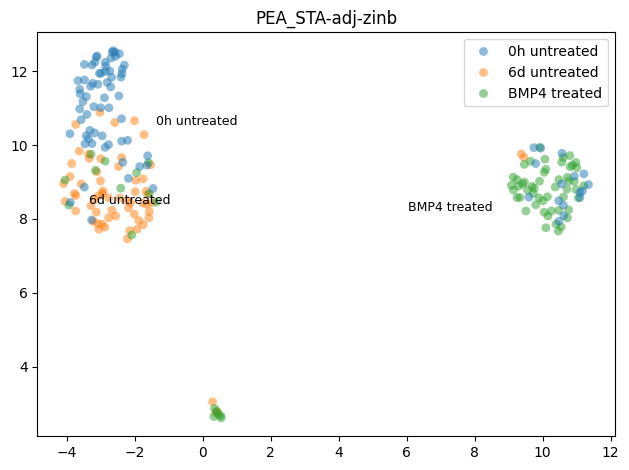

In [16]:
plot_embedding('PEA_STA', 'adj', 'zinb', cell_stage)


## sci_CAR

In [2]:
hg = load_graph('./data/sci_CAR', load_edges=False)

load_edges=False
Load nodes in 0.01 seconds.
Num nodes: 8939, Num edges: NaN
Metadata: {'dataname': 'sci_CAR', 'filter_edge': False, 'num_cells': 8837, 'num_genes': 100, 'num_omics': 2, 'num_nodes': 8939, 'orig_edges': 883700, 'num_edges': 883700, 'omics_offset': 0, 'gene_offset': 2, 'cell_offset': 102, 'omics_dims': [50, 50], 'raw_data': {'atac': './data/sci_CAR/ATAC_lsi.csv', 'rna': './data/sci_CAR/RNA_pca.csv'}, 'cell_key': 'Unnamed: 0', 'normalize_stats': [], 'normalization': True, 'train_size': 0.8}


In [35]:
cell_stage = None

/home/mscs/congfeng4/GuidedStudy/Code/SCOIT/scoit/cell_analysis.py:164: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


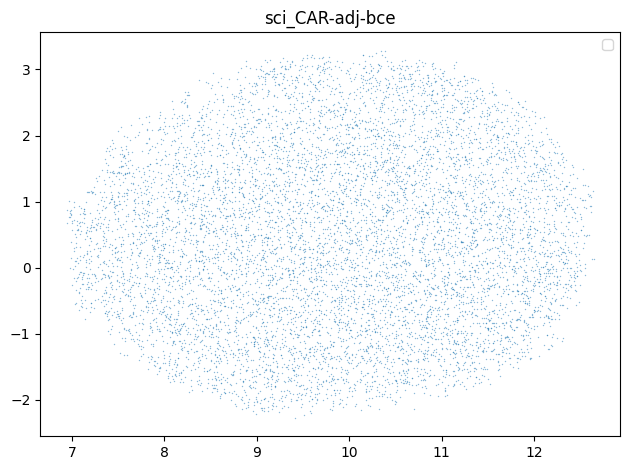

In [36]:
plot_embedding('sci_CAR', 'adj', 'bce', cell_stage, s=1)


In [34]:
plot_embedding('sci_CAR', 'adj', 'mse', cell_stage)


KeyboardInterrupt: 

/home/mscs/congfeng4/GuidedStudy/Code/SCOIT/scoit/cell_analysis.py:164: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


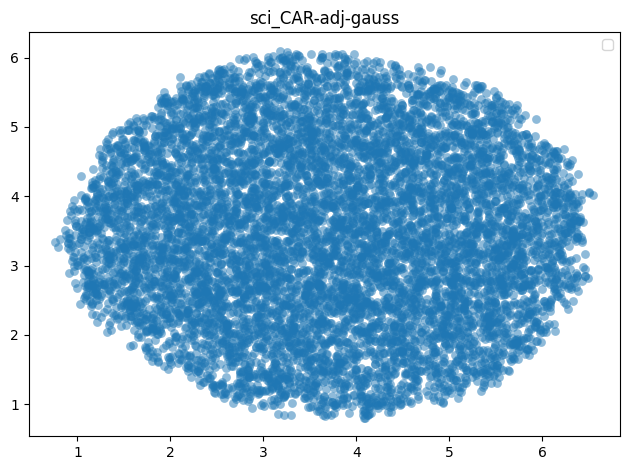

In [6]:
plot_embedding('sci_CAR', 'adj', 'gauss', cell_stage)


## scNMT

In [22]:
hg = load_graph('./data/scNMT', load_edges=False)


load_edges=False
Load nodes in 0.00 seconds.
Num nodes: 2843, Num edges: NaN
Metadata: {'dataname': 'scNMT', 'filter_edge': False, 'num_cells': 1940, 'num_genes': 900, 'num_omics': 3, 'num_nodes': 2843, 'orig_edges': 978300, 'num_edges': 978300, 'omics_offset': 0, 'gene_offset': 3, 'cell_offset': 903, 'omics_dims': [300, 300, 300], 'raw_data': {'expr': './data/scNMT/expression_data_300.csv', 'promoter_acc': './data/scNMT/promoter_acc_data_300.csv', 'promoter_methy': './data/scNMT/promoter_methy_data_300.csv'}, 'cell_key': None}


In [19]:
cell_stage = json.load(open('./data/scNMT/cell_stage.json'))

In [28]:
from collections import Counter

Counter(cell_stage)

Counter({'E7.5': 913, 'E6.5': 854, 'E5.5': 173})

{'NMI': 0.030891370660749786,
 'ARI': 0.030360560273595166,
 'FMI': 0.4783207284337428}

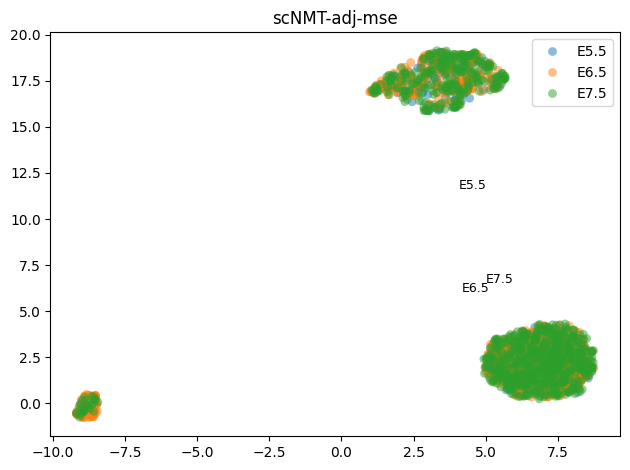

In [20]:
plot_embedding('scNMT', 'adj', 'mse', cell_stage)


{'NMI': 0.030891370660749786,
 'ARI': 0.030360560273595166,
 'FMI': 0.4783207284337428}

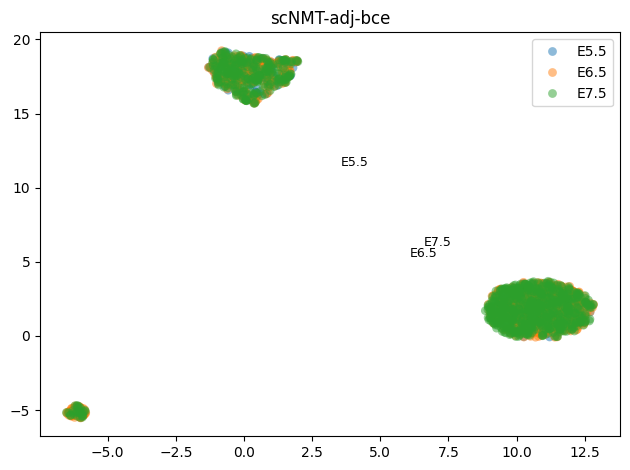

In [21]:
plot_embedding('scNMT', 'adj', 'bce', cell_stage)


/home/mscs/congfeng4/GuidedStudy/Code/SCOIT/scoit/cell_analysis.py:164: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


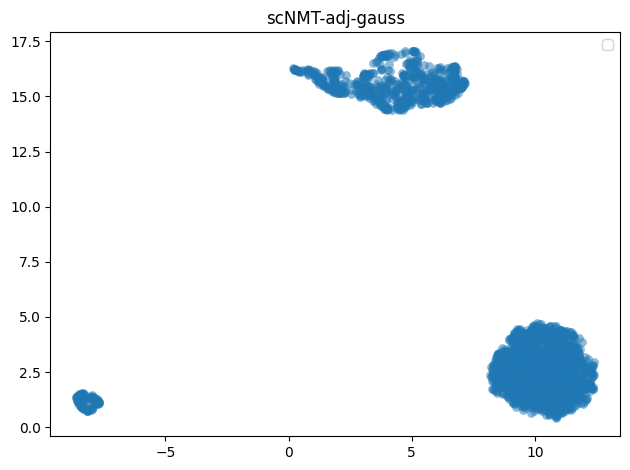

In [9]:
plot_embedding('scNMT', 'adj', 'gauss', cell_stage)

## SNARE_seq_neonatal_mouse

In [ ]:
plot_embedding('SNARE_seq_neonatal_mouse', 'adj', 'bce', None)


## SNARE_seq_adult_mouse

In [ ]:
plot_embedding('SNARE_seq_adult_mouse', 'adj', 'bce', None)


## SCoPE2

In [ ]:
cell_stage = json.load(open('./data/SCoPE2/cell_stage.json'))

: 

In [ ]:
plot_embedding('SCoPE2', 'adj', 'mse', None)


## CITE_seq

In [ ]:
plot_embedding('CITE_seq', 'adj', 'bce', None)
